In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

In [3]:
np.random.seed(7)

city = "Івано-Франківськ"

monthly_temp = [-4, -3, 1, 7, 12, 15, 17, 16, 12, 7, 2, -2]

months = [
    "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
    "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]

rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0,
        30
    )
    heating_days = round(heating_days)

    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

print(climate)

               місто місяць  температура  опалювальні_дні  витрати_на_опалення
0   Івано-Франківськ    Січ           -4               25                  3.3
1   Івано-Франківськ    Лют           -3               21                  3.6
2   Івано-Франківськ    Бер            1               16                  2.4
3   Івано-Франківськ    Кві            7               11                  0.0
4   Івано-Франківськ    Тра           12                8                  1.8
5   Івано-Франківськ    Чер           15                2                  0.1
6   Івано-Франківськ    Лип           17                2                  0.0
7   Івано-Франківськ    Сер           16                2                  0.0
8   Івано-Франківськ    Вер           12                7                  1.2
9   Івано-Франківськ    Жов            7               11                  0.1
10  Івано-Франківськ    Лис            2               18                  2.9
11  Івано-Франківськ    Гру           -2            

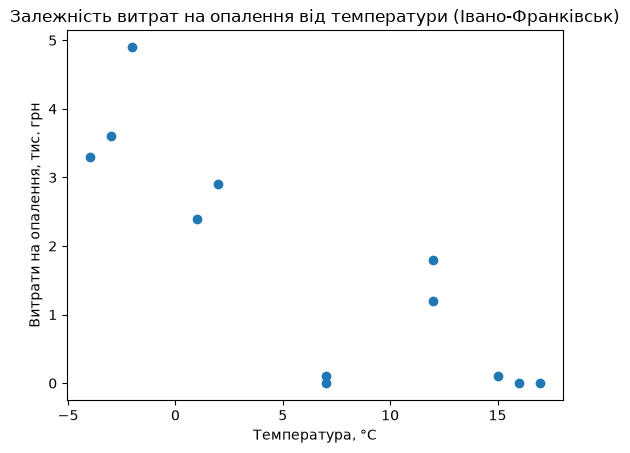

In [6]:
fig, ax = plt.subplots()

ax.scatter(
    climate["температура"],
    climate["витрати_на_опалення"]
)

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Витрати на опалення, тис. грн")
ax.set_title(
    "Залежність витрат на опалення від температури "
    "(Івано-Франківськ)"
)

plt.show()

### Опис діаграми

На діаграмі розсіювання спостерігається переважно негативний зв'язок між температурою та витратами на опалення. При зниженні температури витрати на опалення загалом збільшуються, а при підвищенні температури — зменшуються. Хмара точок має приблизно лінійний характер, хоча через випадковий шум у генерації даних присутні окремі відхилення. Явних аномальних викидів не спостерігається. Такий напрямок зв'язку відповідає інтуїції та коду генерації, оскільки кількість опалювальних днів безпосередньо залежить від температури, а витрати залежать від кількості опалювальних днів.


In [8]:
pearson_result = pearsonr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

spearman_result = spearmanr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

print(
    f"Пірсон: r={pearson_result.statistic:.3f}, "
    f"p={pearson_result.pvalue:.6f}"
)

print(
    f"Спірмен: rho={spearman_result.statistic:.3f}, "
    f"p={spearman_result.pvalue:.6f}"
)

Пірсон: r=-0.842, p=0.000599
Спірмен: rho=-0.837, p=0.000681


In [9]:
confidence_interval = pearson_result.confidence_interval(
    confidence_level=0.95
)

print(
    f"95% довірчий інтервал Пірсона: "
    f"[{confidence_interval.low:.3f}; "
    f"{confidence_interval.high:.3f}]"
)

95% довірчий інтервал Пірсона: [-0.954; -0.518]


### Інтерпретація результатів

Коефіцієнт Пірсона становить приблизно **r = -0.842**, а коефіцієнт Спірмена — **rho = -0.837**. Обидва коефіцієнти мають від'ємний знак і велику абсолютну величину, тому між температурою та витратами на опалення існує сильний негативний зв'язок.

Для обох критеріїв p-value менше за рівень значущості α = 0.05, тому нульову гіпотезу про відсутність кореляції відхиляємо. Отже, зв'язок між температурою та витратами на опалення є статистично значущим.

Значення Пірсона і Спірмена дуже близькі одне до одного. Це узгоджується з діаграмою розсіювання, оскільки залежність має приблизно монотонний та близький до лінійного характер. Тому ранговий коефіцієнт Спірмена дає результат, подібний до коефіцієнта Пірсона.

95%-й довірчий інтервал для істинного коефіцієнта кореляції Пірсона приблизно становить [-0.954; -0.518]. Це означає, що за прийнятою моделлю та вибіркою цей інтервал містить правдоподібні значення істинної кореляції в генеральній сукупності.


In [10]:
correlation_data = climate[
    [
        "температура",
        "опалювальні_дні",
        "витрати_на_опалення"
    ]
]

pearson_matrix = correlation_data.corr()

print("Кореляційна матриця Пірсона:")
print(pearson_matrix.round(3))

Кореляційна матриця Пірсона:
                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.986               -0.842
опалювальні_дні           -0.986            1.000                0.838
витрати_на_опалення       -0.842            0.838                1.000


In [11]:
spearman_matrix = correlation_data.corr(
    method="spearman"
)

print("Кореляційна матриця Спірмена:")
print(spearman_matrix.round(3))

Кореляційна матриця Спірмена:
                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.984               -0.837
опалювальні_дні           -0.984            1.000                0.835
витрати_на_опалення       -0.837            0.835                1.000


### Аналіз кореляційної матриці

Найсильніший зв'язок спостерігається між температурою та кількістю опалювальних днів, а також між температурою та витратами на опалення. Зв'язок між температурою і опалювальними днями є від'ємним: зі зростанням температури кількість опалювальних днів зменшується.

Між опалювальними днями та витратами на опалення спостерігається позитивний зв'язок, оскільки витрати в коді генерації безпосередньо обчислюються на основі кількості опалювальних днів.

Перехід від Пірсона до Спірмена не змінює основних висновків: напрямок і сила зв'язків залишаються подібними. Це очікувано, оскільки для цього набору даних зв'язки мають переважно монотонний характер.


### Кореляція і причинність

Отримана сильна негативна кореляція між температурою та витратами на опалення узгоджується з побудовою цього набору даних. У коді кількість опалювальних днів обчислюється безпосередньо за формулою, яка містить `temp`, а витрати на опалення, у свою чергу, обчислюються на основі кількості опалювальних днів. Тому в цьому штучно згенерованому наборі зв'язок є прямим і закладеним у формули генерації, а не випадковою кореляцією через невідомий конфаундер. На відміну від прикладу «морозиво й утоплення», де спільною причиною може бути температура повітря, тут залежність спеціально створена безпосередньо через формулу. Водночас для реальних даних сама кореляція без додаткового причинного аналізу не була б достатнім доказом причинності.


In [12]:
anomaly = climate.iloc[0].copy()

anomaly["місяць"] = "Аномалія"
anomaly["витрати_на_опалення"] = round(
    climate.iloc[0]["витрати_на_опалення"] * 5,
    1
)

anomaly["місто"] = city

climate_anomaly = pd.concat(
    [climate, pd.DataFrame([anomaly])],
    ignore_index=True
)

print(climate_anomaly)

               місто    місяць  температура  опалювальні_дні  \
0   Івано-Франківськ       Січ           -4               25   
1   Івано-Франківськ       Лют           -3               21   
2   Івано-Франківськ       Бер            1               16   
3   Івано-Франківськ       Кві            7               11   
4   Івано-Франківськ       Тра           12                8   
5   Івано-Франківськ       Чер           15                2   
6   Івано-Франківськ       Лип           17                2   
7   Івано-Франківськ       Сер           16                2   
8   Івано-Франківськ       Вер           12                7   
9   Івано-Франківськ       Жов            7               11   
10  Івано-Франківськ       Лис            2               18   
11  Івано-Франківськ       Гру           -2               19   
12  Івано-Франківськ  Аномалія           -4               25   

    витрати_на_опалення  
0                   3.3  
1                   3.6  
2                   2.4  

In [13]:
pearson_anomaly = pearsonr(
    climate_anomaly["температура"],
    climate_anomaly["витрати_на_опалення"]
)

spearman_anomaly = spearmanr(
    climate_anomaly["температура"],
    climate_anomaly["витрати_на_опалення"]
)

print(
    f"Пірсон з викидом: r={pearson_anomaly.statistic:.3f}, "
    f"p={pearson_anomaly.pvalue:.6f}"
)

print(
    f"Спірмен з викидом: rho={spearman_anomaly.statistic:.3f}, "
    f"p={spearman_anomaly.pvalue:.6f}"
)

Пірсон з викидом: r=-0.635, p=0.019715
Спірмен з викидом: rho=-0.865, p=0.000133


### Контролюючі питання

**1. Чи можете пояснити механіку коефіцієнта кореляції Пірсона — чому він ділиться саме на добуток стандартних відхилень обох змінних, і чому результат завжди в діапазоні [-1; 1]?**

Коефіцієнт Пірсона вимірює силу лінійного зв'язку між двома змінними. Ділення на добуток стандартних відхилень нормалізує спільну зміну змінних і робить коефіцієнт незалежним від одиниць вимірювання. Через властивості коваріації та стандартних відхилень коефіцієнт завжди належить діапазону від -1 до 1. Значення, близькі до -1, означають сильний негативний лінійний зв'язок, а значення, близькі до 1, — сильний позитивний.

**2. Чи можете пояснити, чому коефіцієнт Спірмена рахують на рангах, а не на самих значеннях, і як саме це робить його стійким до викидів?**

Спірмен спочатку замінює фактичні значення їхніми рангами, тобто порядковими позиціями. Через це надзвичайно велике або мале значення не може настільки сильно вплинути на результат, як у випадку Пірсона. Тому коефіцієнт Спірмена є більш стійким до викидів і добре оцінює монотонний зв'язок.

**3. Наведіть приклад ситуації, де r ≈ 0, а зв'язок між змінними насправді є і навіть сильний — і поясніть, чому Пірсон його не показує.**

Прикладом може бути залежність \(y = x^2\), коли значення \(x\) симетрично розподілені навколо нуля. Зв'язок між змінними є дуже чітким і сильним, але він нелінійний. Позитивні та негативні значення \(x\) можуть взаємно компенсуватися, тому лінійний коефіцієнт Пірсона може бути близьким до нуля.

**4. Чому сама по собі сильна кореляція між двома змінними не є доказом, що одна з них впливає на іншу?**

Кореляція показує статистичний зв'язок, але сама по собі не встановлює причинно-наслідковий механізм. Дві змінні можуть бути пов'язані через третю змінну — конфаундер — або зв'язок може бути зумовлений особливостями вибірки чи способом отримання даних. Тому для доведення причинності потрібен додатковий аналіз і відповідний дизайн дослідження.
